In [61]:
import pandas as pd


In [62]:
pd.read_csv("data/Jumlah Penumpang Kereta Api, 2016.csv")

,Kereta Api,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,Jumlah Penumpang Kereta Api (Ribu Orang),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
3,Jabodetabek,22238,21229,23206,23149,24401,23821,21574,23923,23570,24533,24104,24841,-
4,Non Jabodetabek (Jawa),5648,4829,4950,4851,5775,4909,6642,5202,5448,5232,5074,6689,-
5,Jawa (Jabodetabek+Non Jabodetabek),27886,26058,28156,28000,30176,28730,28216,29125,29019,29765,29178,31530,-
6,Non Jawa (Sumatera + Sulawesi),472,453,461,434,527,429,615,463,497,498,512,620,-
7,Kereta Bandara,-,-,-,-,-,-,-,-,-,-,-,-,-
8,MRT,-,-,-,-,-,-,-,-,-,-,-,-,-
9,LRT,-,-,-,-,-,-,-,-,-,-,-,-,-


In [63]:
import glob
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
month_map = {
    "Januari": 1,
    "Februari": 2,
    "Maret": 3,
    "April": 4,
    "Mei": 5,
    "Juni": 6,
    "Juli": 7,
    "Agustus": 8,
    "September": 9,
    "Oktober": 10,
    "November": 11,
    "Desember": 12
}

list_data = []

for file in sorted(glob.glob("data/*.csv")):
    with open(file, "r", encoding="utf-8") as f:
        lines = [f.readline() for _ in range(3)]
        tahun = re.sub(r"[^0-9]", "", lines[2])
    if not tahun:
        continue

    df = pd.read_csv(file, skiprows=3)
    df = df.rename(columns={df.columns[0]: "Kategori"})

    if "Tahunan" in df.columns:
        df = df.drop(columns=["Tahunan"])

    df_long = df.melt(
        id_vars=["Kategori"], var_name="Bulan", value_name="Jumlah Penumpang"

    )

    df_long["Tahun"] = tahun

    df_long["Jumlah Penumpang"] = pd.to_numeric(df_long["Jumlah Penumpang"].astype(str).str.replace("-", "0"), errors="coerce",).fillna(0)
    list_data.append(df_long)

C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\3824160502.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\3824160502.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\3824160502.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\3824160502.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\Carol\AppData\Local\Temp\ipykernel_16632\3824160502.py:35: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\C

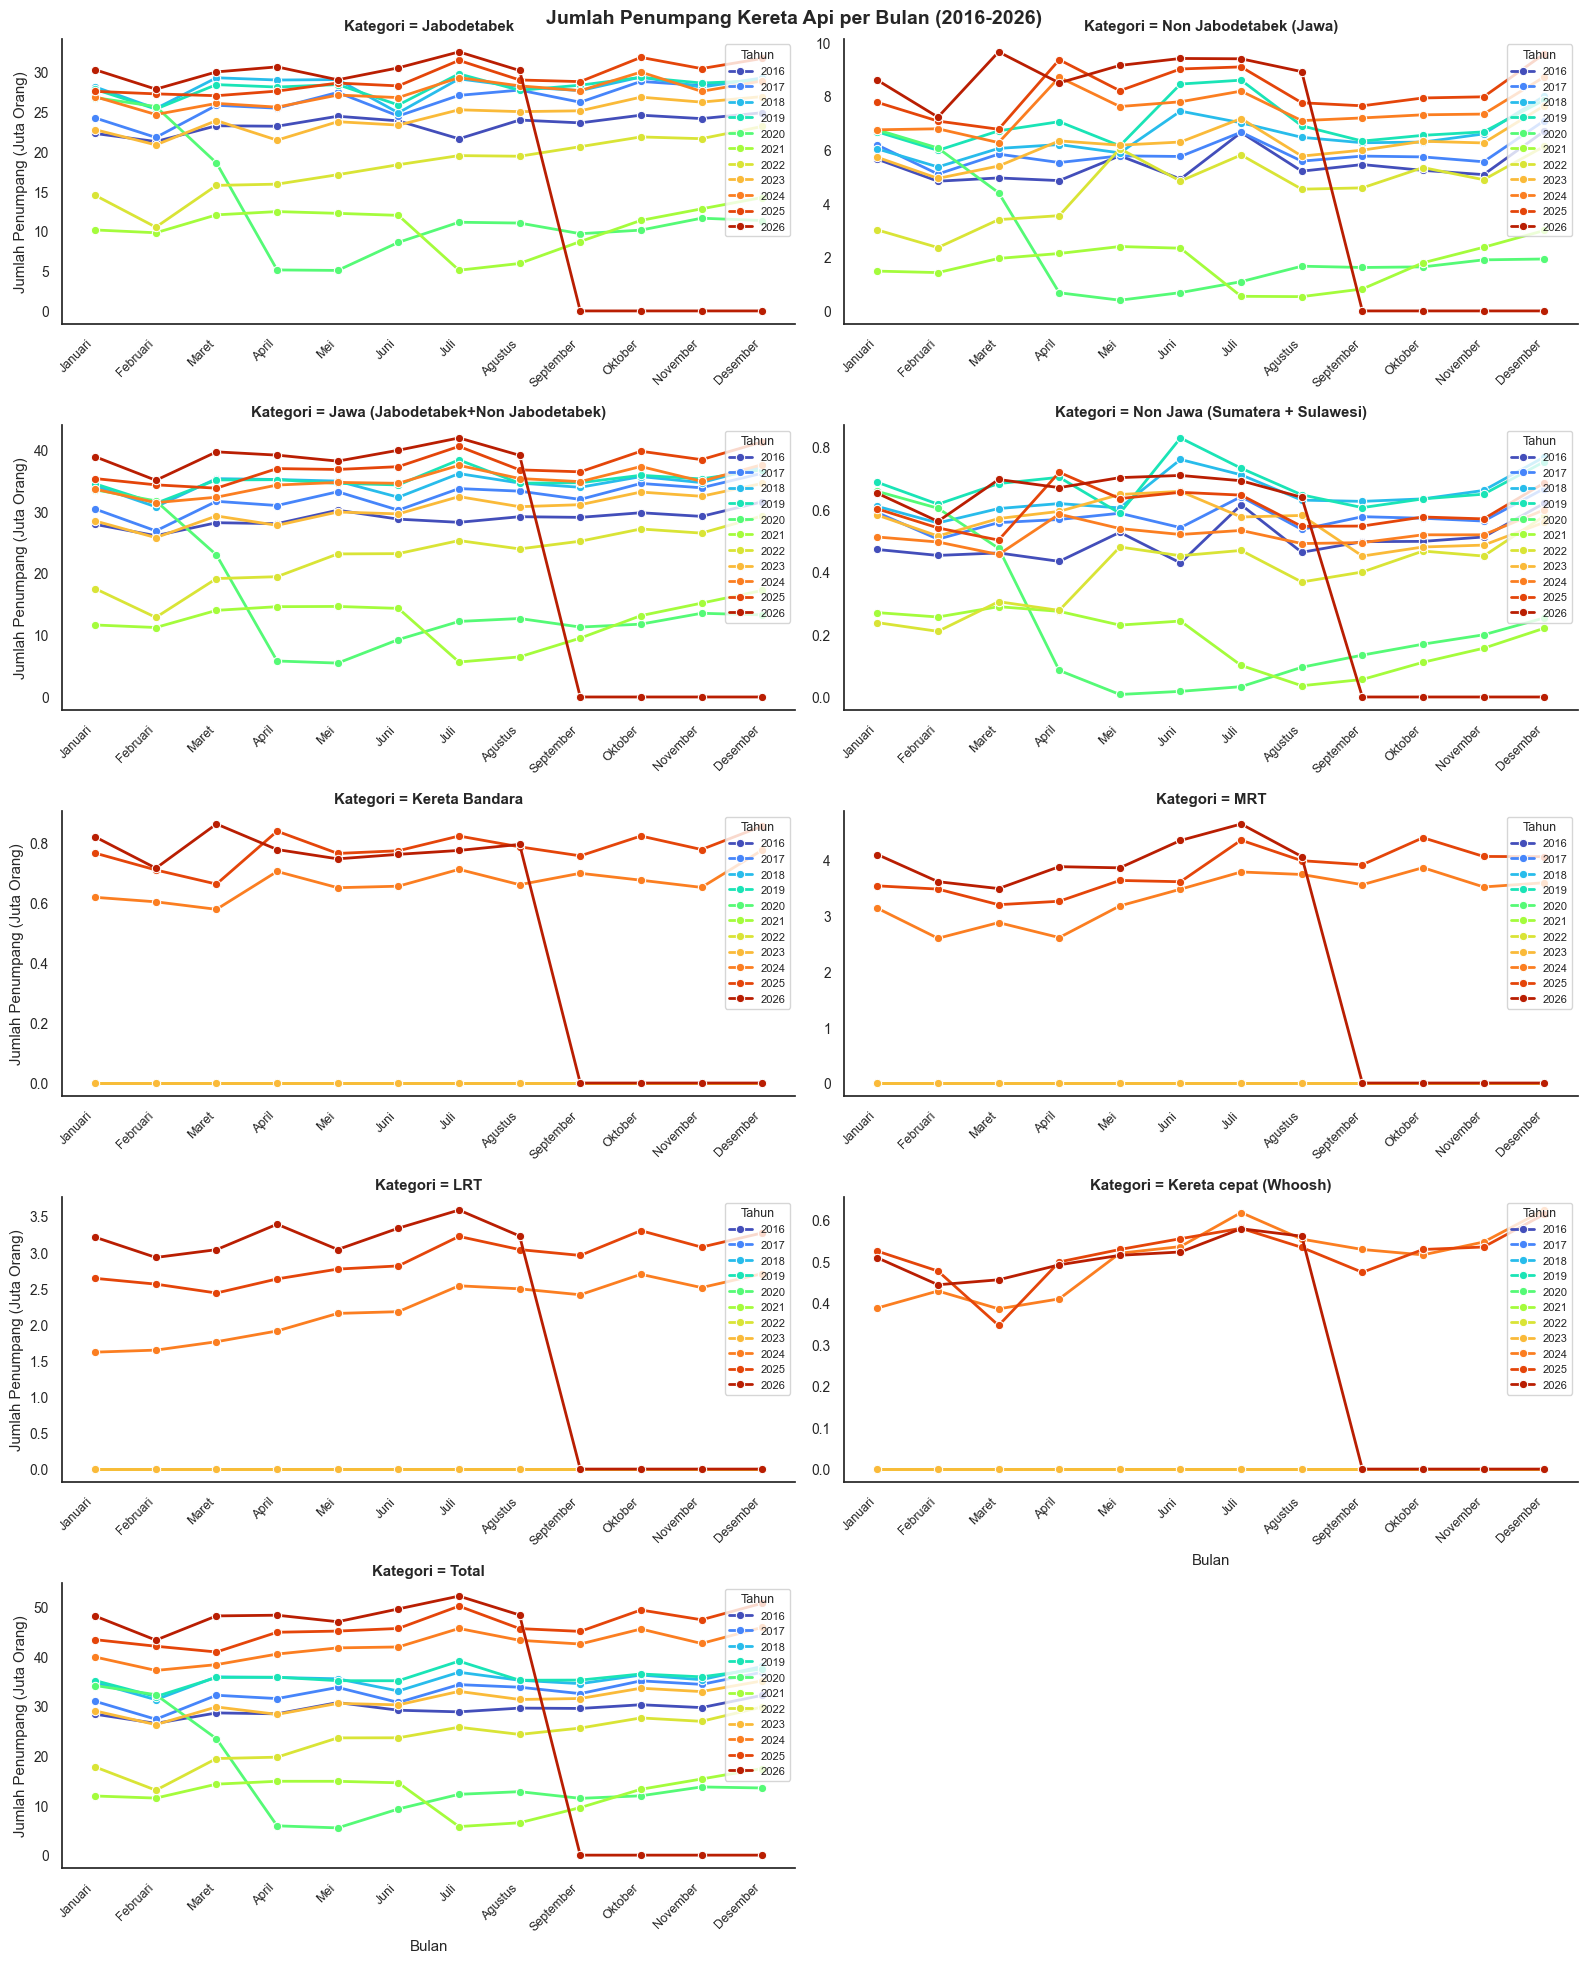

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

month_order = [
    'Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
    'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember',
]

data_utama['Bulan'] = pd.Categorical(
    data_utama['Bulan'], categories=month_order, ordered=True
)

# Ubah dari ribu orang menjadi juta orang
data_utama['Penumpang (Juta)'] = data_utama['Jumlah Penumpang'] / 1000

g = sns.FacetGrid(
    data=data_utama,
    col='Kategori',
    hue='Tahun',
    col_wrap=2,
    height=4,
    aspect=2,
    sharey=False,
    sharex=False,
    palette='turbo',
)

g.map_dataframe(
    sns.lineplot, x='Bulan', y='Penumpang (Juta)', marker='o', linewidth=2
)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True)
    ax.set_xticklabels(month_order, rotation=45, ha='right', fontsize=9)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(
            handles=handles,
            labels=labels,
            loc='upper right',
            title='Tahun',
            fontsize=8,
            title_fontsize=9,
        )

g.set_axis_labels('Bulan', 'Jumlah Penumpang (Juta Orang)')
g.fig.subplots_adjust(top=0.92, hspace=0.4)  # kurung tutup yang tadi hilang
g.fig.suptitle(
    'Jumlah Penumpang Kereta Api per Bulan (2016-2026)',
    fontsize=14,
    fontweight='bold',
)

plt.tight_layout()
plt.show()

In [67]:
import plotly.express as px

data_utama = data_utama.sort_values('Tanggal')

# Ubah dari ribu orang menjadi juta orang
data_utama['Penumpang (Juta)'] = data_utama['Jumlah Penumpang'] / 1000

fig = px.line(
    data_utama[~data_utama['Kategori'].isin(['Total'])],
    x='Tanggal',
    y='Penumpang (Juta)',
    color='Kategori',
    title='Dinamika Penumpang Kereta Api Indonesia (2016-2026)',
    labels={
        'Penumpang (Juta)': 'Jumlah Penumpang (Juta Orang)',
        'Tanggal': 'Periode Waktu',
    },
    template='plotly_white',
)

fig.update_traces(mode='lines+markers', hovertemplate='%{x}<br>%{y:.2f} juta')
fig.update_layout(
    hovermode='x unified',
    legend_title_text='Kategori Transportasi',
    font=dict(size=12),
)

fig.show()

In [ ]:
import numpy as np
import plotly.express as px
df = data_utama.copy()
df['Penumpang (Juta)'] = df['Jumlah Penumpang'] / 1000
df = df.dropna(subset=['Jumlah Penumpang'])
df = df[df['Jumlah Penumpang'] > 0]
tahunan = (
    df.groupby(['Kategori', 'Tahun'])['Penumpang (Juta)']
    .mean()
    .reset_index(name='Rata-rata per Bulan (Juta)')
    .sort_values(['Kategori', 'Tahun'])
)
tahunan['Pertumbuhan YoY (%)'] = (
    tahunan.groupby('Kategori')['Rata-rata per Bulan (Juta)'].pct_change() * 100
)
total = tahunan[tahunan['Kategori'] == 'Total'].dropna(subset=['Pertumbuhan YoY (%)']).copy()
total['Arah'] = np.where(total['Pertumbuhan YoY (%)'] >= 0, 'Naik', 'Turun')

fig1 = px.bar(
    total,
    x='Tahun',
    y='Pertumbuhan YoY (%)',
    color='Arah',
    color_discrete_map={'Naik': '#2e9e5b', 'Turun': '#d64545'},
    text=total['Pertumbuhan YoY (%)'].map('{:+.1f}%'.format),
    title='Pertumbuhan Total Penumpang Kereta Api per Tahun (YoY)',
    template='plotly_white',
)
fig1.update_traces(textposition='outside')
fig1.update_xaxes(type='category')
fig1.update_layout(legend_title_text='Arah Tren')
fig1.show()
pivot = (
    tahunan[~tahunan['Kategori'].isin(['Total'])]
    .pivot(index='Kategori', columns='Tahun', values='Pertumbuhan YoY (%)')
)

fig2 = px.imshow(
    pivot,
    text_auto='.1f',
    aspect='auto',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    labels={'color': 'YoY (%)', 'x': 'Tahun', 'y': 'Kategori'},
    title='Heatmap Pertumbuhan Penumpang per Kategori (YoY, %)',
)
fig2.update_xaxes(type='category')
fig2.show()

In [69]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = data_utama.copy()
df['Penumpang (Juta)'] = df['Jumlah Penumpang'] / 1000
df = df.dropna(subset=['Jumlah Penumpang'])
df = df[df['Jumlah Penumpang'] > 0]

month_order = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni',
               'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
exclude = ['Total', 'Jawa']
df_kat = df[~df['Kategori'].isin(exclude)]
tot = df[df['Kategori'] == 'Total'].copy()
tot['Bulan'] = pd.Categorical(tot['Bulan'], categories=month_order, ordered=True)
pivot_musim = tot.pivot_table(index='Tahun', columns='Bulan',
                              values='Penumpang (Juta)', observed=False)

fig1 = px.imshow(
    pivot_musim, text_auto='.1f', aspect='auto',
    color_continuous_scale='YlOrRd',
    labels={'color': 'Juta Orang', 'x': 'Bulan', 'y': 'Tahun'},
    title='Pola Musiman Total Penumpang (Juta Orang)',
)
fig1.update_yaxes(type='category')
fig1.show()
komposisi = (df_kat.groupby(['Tahun', 'Kategori'])['Penumpang (Juta)']
             .mean().reset_index())
komposisi['Porsi (%)'] = (komposisi['Penumpang (Juta)']
                          / komposisi.groupby('Tahun')['Penumpang (Juta)'].transform('sum') * 100)

fig2 = px.area(
    komposisi, x='Tahun', y='Porsi (%)', color='Kategori',
    title='Perubahan Komposisi Penumpang per Kategori (%)',
    template='plotly_white',
)
fig2.update_xaxes(type='category')
fig2.show()
tahunan = (df_kat.groupby(['Kategori', 'Tahun'])['Penumpang (Juta)']
           .mean().reset_index())
basis = tahunan[tahunan['Tahun'] == 2019].set_index('Kategori')['Penumpang (Juta)']
tahunan['Indeks'] = tahunan.apply(
    lambda r: r['Penumpang (Juta)'] / basis[r['Kategori']] * 100
    if r['Kategori'] in basis.index else np.nan, axis=1)

fig3 = px.line(
    tahunan.dropna(subset=['Indeks']), x='Tahun', y='Indeks', color='Kategori',
    markers=True, template='plotly_white',
    title='Pemulihan Penumpang Dibanding 2019 (2019 = 100)',
)
fig3.add_hline(y=100, line_dash='dash', line_color='gray',
               annotation_text='Level 2019')
fig3.update_xaxes(type='category')
fig3.show()